In [ ]:
# 실습 라이브러리(lib) 준비 — 교재 저장소에서 자동으로 받아옵니다 (Google Drive 불필요)
import os, sys
path = "/content/"
if not os.path.isdir(path + "lib"):
    !git clone -q --depth 1 https://github.com/AI-BoostCamp/ReinforcementLearning.git /content/_rl && cp -r /content/_rl/code/lib /content/lib && rm -rf /content/_rl
sys.path.append(path + "lib")
os.makedirs(path + "models/DRL", exist_ok=True)   # 학습된 모델 저장 위치 (세션 종료 시 사라짐)


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [5, 3.5]
plt.rcParams["font.size"] = "8"

from queue import PriorityQueue

from variable_print import p,ps,pst
from gridworld import GridworldEnv
from temporal_difference import TDAgent
from grid_visualization import visualize_value_function, visualize_policy

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
np.random.seed(0)

## 초기화

### `GridWorld` 초기화하기

`GridworldEnv`생성

In [4]:
nx, ny = 4, 4
env = GridworldEnv([ny, nx])

### QLearner Agent 생성  
`SARSA`: TDAgent를 상속받아 구현  

**행동정책 : epsilon-greedy policy 적용**

In [5]:
class QLearner(TDAgent):

    def __init__(self,
                 gamma: float,
                 num_states: int,
                 num_actions: int,
                 epsilon: float,
                 lr: float):
        super(QLearner, self).__init__(gamma=gamma,
                                       num_states=num_states,
                                       num_actions=num_actions,
                                       epsilon=epsilon,
                                       lr=lr,
                                       n_step=1)

    def get_action(self, state, mode='train'):
        if mode == 'train':
            prob = np.random.uniform(0.0, 1.0, 1)
            # e-greedy policy over Q
            if prob <= self.epsilon:  # random
                action = np.random.choice(range(self.num_actions))
            else:  # greedy
                action = self.q[state, :].argmax()
        else:
            action = self.q[state, :].argmax()
        return action

    def update_sample(self, state, action, reward, next_state, done):
        s, a, r, ns = state, action, reward, next_state
        # Q-Learning target
        td_target = r + self.gamma * self.q[ns, :].max() * (1 - done)
        self.q[s, a] += self.lr * (td_target - self.q[s, a])

In [6]:
qlearning_agent = QLearner(gamma=1.0,        # 감가율
                           lr=1e-1,          # learning rate
                           num_states=env.nS,
                           num_actions=env.nA,
                           epsilon=0.5)      # epsilon-greedy 적용

## Q-learning update method
**평가정책: greedy policy 적용**

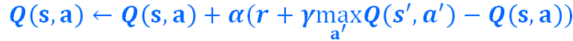

## Q-Learning 시행

In [8]:
%%time
qlearning_agent.reset_values() # v, q <- 0

num_eps = 1000
report_every = 200
qlearning_qs = []
iter_idx = []

path_length = 0
for i in range(num_eps):  # 시행할 episode
    env.reset()           # s <- random state
    while True:           # Terminal 상태까지 반복
        state = env.s                                       # s : random
        action = qlearning_agent.get_action(state)          # a <- pi(s,a)
        next_state, reward, done, info = env.step(action)   # s' <- step(a)
        qlearning_agent.update_sample(state=state,          # s
                                      action=action,        # a
                                      reward=reward,        # r
                                      next_state=next_state,# s'
                                      done=done)
        path_length += 1 # episode 길이
        if done: break
    if i % report_every == 0:
        print(f">>Mean Length : {path_length/report_every}")# sum(epi길이)/report_every
        qlearning_qs.append(qlearning_agent.q.copy())       #시각화를 위해 q(s,a)보관
        iter_idx.append(i)
        path_length = 0

>>Mean Length : 0.005
>>Mean Length : 6.52
>>Mean Length : 3.43
>>Mean Length : 3.535
>>Mean Length : 3.455
CPU times: user 155 ms, sys: 40.3 ms, total: 195 ms
Wall time: 173 ms


## 결과 시각화

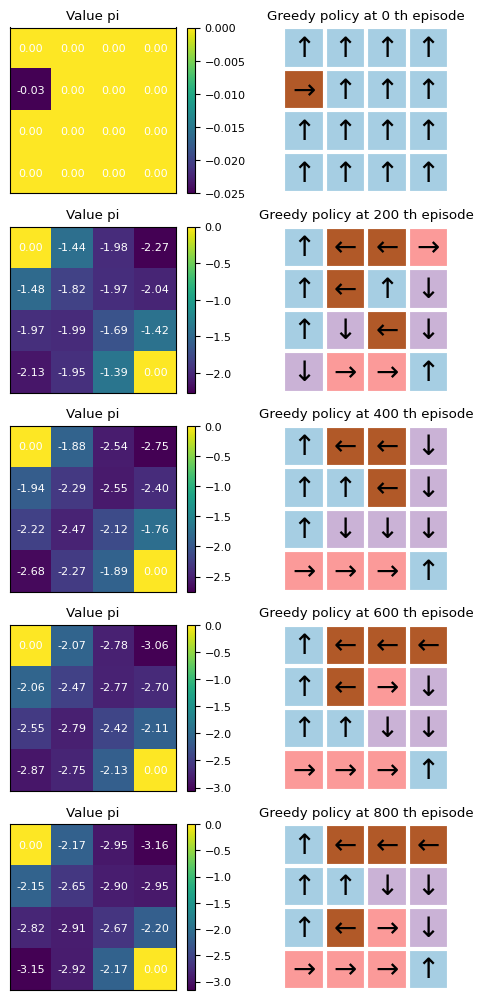

In [9]:
num_plots = len(qlearning_qs)
fig, ax = plt.subplots(num_plots,2, figsize=(6, num_plots*2.5))
for i, (q, viz_i) in enumerate(zip(qlearning_qs, iter_idx)):
    visualize_value_function(ax[i][0], np.sum(q,axis=1)/4, nx, ny) #V(s)=sum(Q(s,a))/4
    _ = ax[i][0].set_title("Value pi")
    visualize_policy(ax[i][1], q, env.shape[0], env.shape[1])
    _ = ax[i][1].set_title("Greedy policy at {} th episode".format(viz_i))

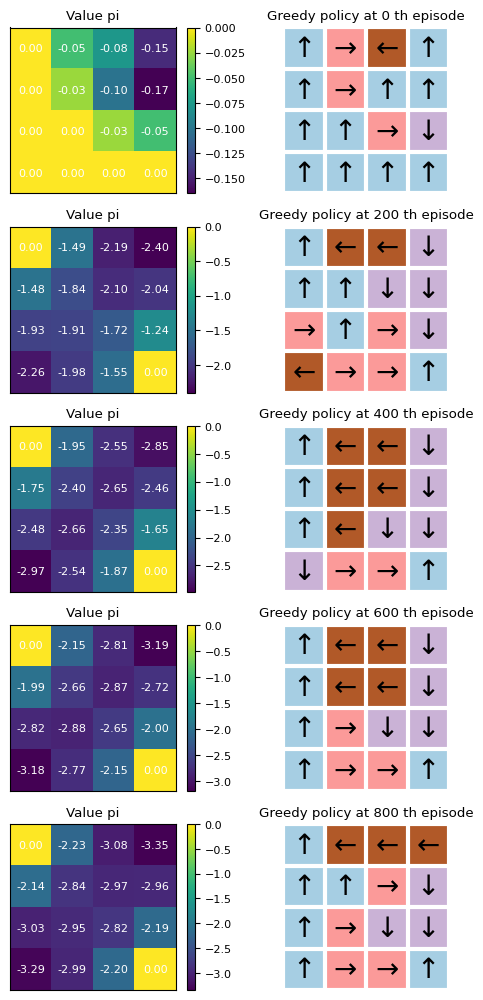